In [1]:
import pandas as pd

X_train = pd.read_csv("../data/preprocessed/X_train.csv")
X_test = pd.read_csv("../data/preprocessed/X_test.csv")

y_train = pd.read_csv("../data/preprocessed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/preprocessed/y_test.csv").values.ravel()

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

models = {
    "Logistic": LogisticRegression(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, prob)
    print(name, "ROC:", roc)

Logistic ROC: 0.833640919185592
DecisionTree ROC: 0.6637111678253982
RandomForest ROC: 0.8104852695280347
KNN ROC: 0.780577830005539


### Model Comparison on ROC-AUC

| Model | ROC-AUC Score |
|-------|---------------|
| Logistic Regression | 0.834 |
| Decision Tree       | 0.657 |
| Random Forest       | 0.814 |
| K-Nearest Neighbors | 0.781 |

## Model Performance Summary

The Logistic Regression model achieved:

Accuracy: 80%

ROC-AUC: 0.83

The model shows good ability to distinguish churners from non-churners.
Key factors influencing churn include contract type, tenure, and monthly charges.

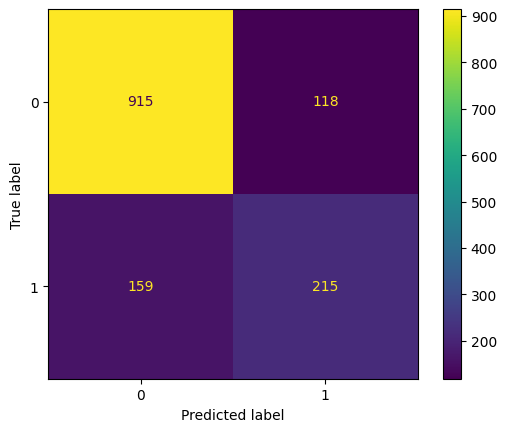

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

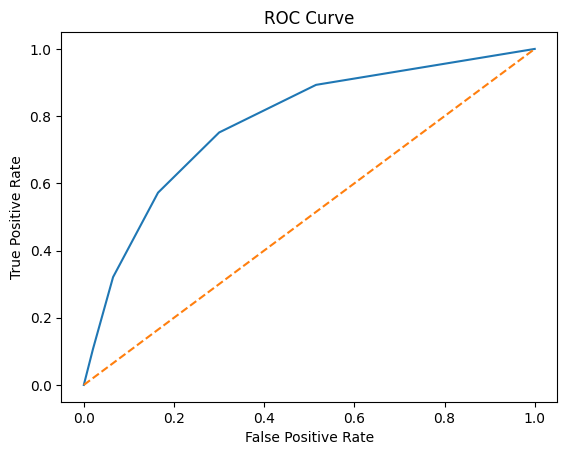

ROC AUC: 0.780577830005539


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC AUC:", roc_auc_score(y_test, y_prob))